In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

rng = np.random.default_rng(0)
C = np.sqrt(2 / np.pi)   # E|z| for z ~ N(0,1)
print(C)

0.7978845608028654


In [2]:
# z = (D-M)/sigma is dimensionless: if the model is perfect, z ~ N(0,1) whatever sigma is
z = rng.normal(0, 1, 10_000_000)
print("E|z|    analytic", C,   "  num", np.abs(z).mean())
print("E[z^2]  analytic", 1.0, "  num", (z ** 2).mean())

E|z|    analytic 0.7978845608028654   num 0.7973814269363122
E[z^2]  analytic 1.0   num 0.99900763194018


In [3]:
# perfect model, pure noise
for N in (10**3, 10**4, 10**5, 10**6):
    z = rng.normal(0, 1, N)
    print(f"N={N:8d}  chi2={(z**2).sum():12.1f}  chi2/N={(z**2).mean():.3f}"
          f"   sum|z|={np.abs(z).sum():12.1f}  sum|z|/N={np.abs(z).mean():.3f}")

N=    1000  chi2=      1059.1  chi2/N=1.059   sum|z|=       830.8  sum|z|/N=0.831
N=   10000  chi2=      9786.3  chi2/N=0.979   sum|z|=      7901.7  sum|z|/N=0.790
N=  100000  chi2=    100701.1  chi2/N=1.007   sum|z|=     80053.5  sum|z|/N=0.801
N= 1000000  chi2=   1001059.0  chi2/N=1.001   sum|z|=    798451.5  sum|z|/N=0.798


In [4]:
# no noise at all
mu = 0.5
for Ngal in (1000, 2000, 4000, 8000):
    z = np.full(Ngal, mu)
    print(f"Ngal={Ngal:6d}  sum|z|={np.abs(z).sum():9.1f}  sum|z|/Ngal={np.abs(z).mean():.3f}"
          f"   chi2={(z**2).sum():9.1f}  chi2/Ngal={(z**2).mean():.3f}")

Ngal=  1000  sum|z|=    500.0  sum|z|/Ngal=0.500   chi2=    250.0  chi2/Ngal=0.250
Ngal=  2000  sum|z|=   1000.0  sum|z|/Ngal=0.500   chi2=    500.0  chi2/Ngal=0.250
Ngal=  4000  sum|z|=   2000.0  sum|z|/Ngal=0.500   chi2=   1000.0  chi2/Ngal=0.250
Ngal=  8000  sum|z|=   4000.0  sum|z|/Ngal=0.500   chi2=   2000.0  chi2/Ngal=0.250


In [5]:
# noise + mismatch
mu = 0.5
for Ngal in (1000, 2000, 4000, 8000):
    z = rng.normal(mu, 1, Ngal)
    lin = np.abs(z).sum() - C * Ngal
    chi = (z ** 2).sum() - Ngal
    print(f"Ngal={Ngal:6d}  lin={lin:8.1f}  lin/Ngal={lin/Ngal:.4f}"
          f"   chi2ex={chi:9.1f}  chi2ex/Ngal={chi/Ngal:.4f}")

Ngal=  1000  lin=   103.4  lin/Ngal=0.1034   chi2ex=    273.3  chi2ex/Ngal=0.2733
Ngal=  2000  lin=   168.6  lin/Ngal=0.0843   chi2ex=    397.6  chi2ex/Ngal=0.1988
Ngal=  4000  lin=   460.7  lin/Ngal=0.1152   chi2ex=   1150.5  chi2ex/Ngal=0.2876
Ngal=  8000  lin=   794.0  lin/Ngal=0.0992   chi2ex=   2102.7  chi2ex/Ngal=0.2628


In [6]:
def E_absz(mu):
    return C * np.exp(-mu**2 / 2) + mu * erf(mu / np.sqrt(2))

for mu in (0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 3.0):
    num = np.abs(rng.normal(mu, 1, 2_000_000)).mean()
    print(f"mu={mu:4.2f}  E|z| exact={E_absz(mu):.4f}  num={num:.4f}"
          f"   lin excess={E_absz(mu)-C:.4f}  approx={C*mu**2/2:.4f}"
          f"   chi2 excess={mu**2:.4f}")

mu=0.00  E|z| exact=0.7979  num=0.7983   lin excess=0.0000  approx=0.0000   chi2 excess=0.0000
mu=0.10  E|z| exact=0.8019  num=0.8011   lin excess=0.0040  approx=0.0040   chi2 excess=0.0100
mu=0.25  E|z| exact=0.8227  num=0.8229   lin excess=0.0248  approx=0.0249   chi2 excess=0.0625
mu=0.50  E|z| exact=0.8956  num=0.8960   lin excess=0.0977  approx=0.0997   chi2 excess=0.2500
mu=1.00  E|z| exact=1.1666  num=1.1672   lin excess=0.3687  approx=0.3989   chi2 excess=1.0000
mu=2.00  E|z| exact=2.0170  num=2.0179   lin excess=1.2191  approx=1.5958   chi2 excess=4.0000
mu=3.00  E|z| exact=3.0008  num=3.0013   lin excess=2.2029  approx=3.5905   chi2 excess=9.0000


In [7]:
# summing over the whole cube instead of the mask adds no signal, only variance
Ntot = 128 * 128 * 64
mu = 0.5
for Ngal in (2_000, 50_000):
    full, mask = [], []
    for _ in range(50): # repeat to get statistics
        z = rng.normal(0, 1, Ntot)
        z[:Ngal] += mu # add signal to the first Ngal voxels
        full.append((z**2).sum() - Ntot)
        mask.append((z[:Ngal]**2).sum() - Ngal)
    f, m = np.array(full), np.array(mask)
    print(f"Ngal={Ngal:6d}  whole cube {f.mean():9.1f} +/- {f.std():7.1f}  S/N={f.mean()/f.std():5.2f}")
    print(f"{'':13s}  mask only  {m.mean():9.1f} +/- {m.std():7.1f}  S/N={m.mean()/m.std():5.2f}")

Ngal=  2000  whole cube     668.5 +/-  1578.9  S/N= 0.42
               mask only      505.2 +/-    70.0  S/N= 7.21
Ngal= 50000  whole cube   12713.5 +/-  1380.7  S/N= 9.21
               mask only    12585.3 +/-   431.3  S/N=29.18


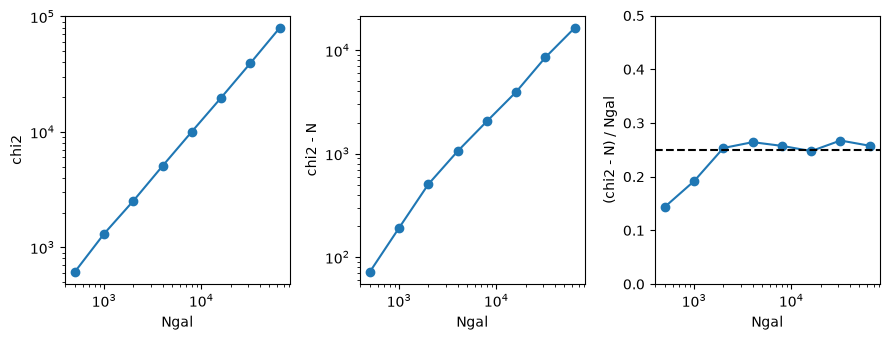

In [8]:
mu = 0.5
Ns = np.array([500, 1000, 2000, 4000, 8000, 16000, 32000, 64000])
raw_sub = np.array([(rng.normal(mu, 1, N)**2).sum() - N for N in Ns])
raw = np.array([(rng.normal(mu, 1, N)**2).sum() for N in Ns])

fig, ax = plt.subplots(1, 3, figsize=(9, 3.5))
ax[0].loglog(Ns, raw, "o-")
ax[0].set_xlabel("Ngal"); ax[0].set_ylabel("chi2")
ax[1].loglog(Ns, raw_sub, "o-")
ax[1].set_xlabel("Ngal"); ax[1].set_ylabel("chi2 - N")
ax[2].semilogx(Ns, raw_sub / Ns, "o-")
ax[2].axhline(mu**2, ls="--", c="k")
ax[2].set_xlabel("Ngal"); ax[2].set_ylabel("(chi2 - N) / Ngal"); ax[2].set_ylim(0, 2 * mu**2)
plt.tight_layout()

## asymmetry

In [ ]:
# one voxel pair, sigma = 5: the galaxy cancels in I(r) - I(-r), only real d = asymmetry + noise is left
sig = 5.0
floor = 2 / np.sqrt(np.pi) * sig # E|n - n'| for pure noise
for Delta in (0, 4, 10, 20):
    d = Delta + rng.normal(0, sig, 1_000_000) - rng.normal(0, sig, 1_000_000)
    print(f"Delta={Delta:3d}  <|d|>={np.abs(d).mean():6.2f}  lin excess={np.abs(d).mean() - floor:6.2f}"
          f"   <d^2> - 2sig^2={np.mean(d**2) - 2 * sig**2:6.1f}  (Delta^2={Delta**2})")

Delta=  0  <|d|>=  5.63  lin excess= -0.01   <d^2> - 2sig^2=  -0.1  (Delta^2=0)
Delta=  4  <|d|>=  6.53  lin excess=  0.88   <d^2> - 2sig^2=  16.1  (Delta^2=16)
Delta= 10  <|d|>= 10.49  lin excess=  4.85   <d^2> - 2sig^2=  99.8  (Delta^2=100)
Delta= 20  <|d|>= 20.02  lin excess= 14.38   <d^2> - 2sig^2= 400.4  (Delta^2=400)


In [ ]:
n = 41
x = np.arange(n) - n // 2
X, Y, V = np.meshgrid(x, x, x, indexing="ij")
sym = np.exp(-(X**2 + Y**2) / (2 * 6**2) - V**2 / (2 * 5**2)) # peak = 1
lop = sym * (1 + 0.3 * np.tanh(X / 6)) # brighter on one side
mask = sym > 0.02 # symmetric in r -> -r
N = mask.sum()

def asym(I, sig):
    Ir = I[::-1, ::-1, ::-1]
    d, s = (I - Ir)[mask], (I + Ir)[mask]
    raw = np.abs(d).sum() / np.abs(s).sum()
    lin = (np.abs(d).sum() - 2 / np.sqrt(np.pi) * sig * N) / s.sum()
    sq = (np.sum(d**2) - 2 * N * sig**2) / (np.sum(s**2) - 2 * N * sig**2)
    return raw, lin, sq

true_lin, _, true_sq = asym(lop, 0)
print(f"noise-free lopsided: A_lin={true_lin:.3f}  A_sq={true_sq:.4f}")

snrs = np.array([1, 2, 3, 5, 10, 20, 50, 100])
res = {}
for name, S in (("sym", sym), ("lop", lop)):
    res[name] = np.array([np.mean([asym(S + rng.normal(0, 1 / snr, S.shape), 1 / snr)
                                   for _ in range(20)], axis=0) for snr in snrs])

for snr, a, b in zip(snrs, res["sym"], res["lop"]):
    print(f"S/N={snr:3d}  mask<S/N5={np.mean(sym[mask] * snr < 5):.2f}"
          f"   sym: raw={a[0]:.3f} lin={a[1]:+.3f} sq={a[2]:+.4f}"
          f"   lop: raw={b[0]:.3f} lin={b[1]:+.3f} sq={b[2]:+.4f}")

noise-free lopsided: A_lin=0.163  A_sq=0.0246
S/N=  1  mask<S/N5=1.00   sym: raw=0.944 lin=+0.001 sq=+0.0011   lop: raw=0.949 lin=+0.010 sq=+0.0569
S/N=  2  mask<S/N5=1.00   sym: raw=0.831 lin=-0.004 sq=-0.0073   lop: raw=0.840 lin=+0.015 sq=+0.0357
S/N=  3  mask<S/N5=1.00   sym: raw=0.716 lin=-0.001 sq=+0.0000   lop: raw=0.726 lin=+0.016 sq=+0.0236
S/N=  5  mask<S/N5=1.00   sym: raw=0.542 lin=-0.001 sq=-0.0001   lop: raw=0.562 lin=+0.026 sq=+0.0247
S/N= 10  mask<S/N5=0.93   sym: raw=0.322 lin=+0.002 sq=+0.0008   lop: raw=0.364 lin=+0.047 sq=+0.0250
S/N= 20  mask<S/N5=0.79   sym: raw=0.170 lin=+0.000 sq=-0.0000   lop: raw=0.245 lin=+0.075 sq=+0.0246
S/N= 50  mask<S/N5=0.55   sym: raw=0.069 lin=+0.000 sq=+0.0000   lop: raw=0.181 lin=+0.112 sq=+0.0246
S/N=100  mask<S/N5=0.33   sym: raw=0.035 lin=+0.000 sq=-0.0000   lop: raw=0.168 lin=+0.133 sq=+0.0246


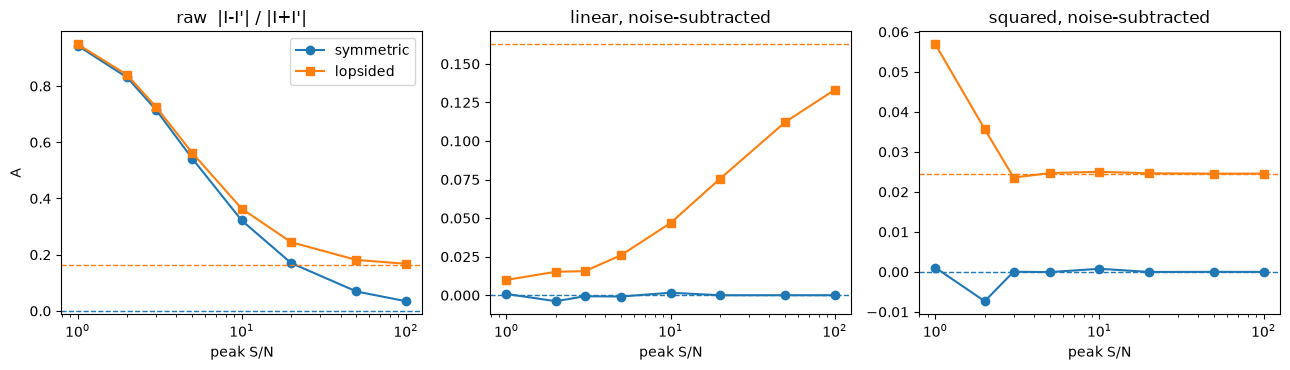

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
titles = ("raw  |I-I'| / |I+I'|", "linear, noise-subtracted", "squared, noise-subtracted")
trues = (true_lin, true_lin, true_sq)
for k in range(3):
    ax[k].semilogx(snrs, res["sym"][:, k], "o-", label="symmetric")
    ax[k].semilogx(snrs, res["lop"][:, k], "s-", label="lopsided")
    ax[k].axhline(0, ls="--", c="C0", lw=1) # true symmetric
    ax[k].axhline(trues[k], ls="--", c="C1", lw=1) # true lopsided
    ax[k].set_title(titles[k])
    ax[k].set_xlabel("peak S/N")
ax[0].set_ylabel("A")
ax[0].legend()
plt.tight_layout()